### *PROYECTO PROCESAMIENTO DE IMÁGENES MÉDICAS*
---
# **Segmentación 3D de Tumores Hepáticos utilizando nnU-Net y HeatMaps de incertidumbre para explicabilidad (XAI)**
---
# **Pre-procesamiento**

In [11]:
!pip install nnunetv2

INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of imagecodecs to determine which version is compatible with other requirements. This could take a while.
  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 81.2 MB/s eta 0:00:00
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)
  Attempting uninstall: tifffile
    Found existing installation: tifffile 2026.4.11
    Uninstalling tifffile-2026.4.11:
      Successfully uninstalled tifffile-2026.4.11
  Attempting uninstall: imagecodecs
    Found existing installation: imagecodecs 2026.6.26
    Uninstalling imagecodecs-2026.6.26:
      Successfully uninstalled imagecodecs-2026.6.26


In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prathamgrover/3d-liver-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '3d-liver-segmentation' dataset.
Path to dataset files: /kaggle/input/3d-liver-segmentation


In [13]:
import os

base_dir = '/content/nnUNet_Workspace'
raw_dir = os.path.join(base_dir, 'nnUNet_raw')
preprocessed_dir = os.path.join(base_dir, 'nnUNet_preprocessed')
results_dir = os.path.join(base_dir, 'nnUNet_results')

os.makedirs(raw_dir, exist_ok=True)
os.makedirs(preprocessed_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

os.environ['nnUNet_raw'] = raw_dir
os.environ['nnUNet_preprocessed'] = preprocessed_dir
os.environ['nnUNet_results'] = results_dir

print("Entorno configurado y carpetas creadas.")

Entorno configurado y carpetas creadas.


In [14]:
import shutil
import os
import nibabel as nib

# Crear estructura del Dataset 101
dataset_id = "Dataset101_Liver"
dataset_path = os.path.join(raw_dir, dataset_id)
imagesTr_path = os.path.join(dataset_path, 'imagesTr')
labelsTr_path = os.path.join(dataset_path, 'labelsTr')

os.makedirs(imagesTr_path, exist_ok=True)
os.makedirs(labelsTr_path, exist_ok=True)

# Ajustamos la ruta al contenido: 'Task03_Liver_rs'
actual_data_path = os.path.join(path, 'Task03_Liver_rs')
print(f"Buscando archivos en: {actual_data_path}")
print(f"Contenido detectado: {os.listdir(actual_data_path)}")

source_images = None
source_labels = None

for f in os.listdir(actual_data_path):
    if 'imag' in f.lower():
        source_images = os.path.join(actual_data_path, f)
    if 'lab' in f.lower():
        source_labels = os.path.join(actual_data_path, f)

if not source_images or not source_labels:
    raise FileNotFoundError(f"No se encontraron carpetas de imágenes o etiquetas en {actual_data_path}.")

print(f"Copiando imágenes desde: {source_images}")
print(f"Copiando etiquetas desde: {source_labels}")

# Mover y renombrar IMÁGENES
for filename in os.listdir(source_images):
    if filename.endswith(".nii"):
        name_part = filename.replace(".nii", "")
        new_name = f"{name_part}_0000.nii.gz"
        src = os.path.join(source_images, filename)
        dst = os.path.join(imagesTr_path, new_name)
        img = nib.load(src)
        nib.save(img, dst)

# Mover y comprimir LABELS
for filename in os.listdir(source_labels):
    if filename.endswith(".nii"):
        new_name = f"{filename}.gz"
        src = os.path.join(source_labels, filename)
        dst = os.path.join(labelsTr_path, new_name)
        img = nib.load(src)
        nib.save(img, dst)

print(f"Archivos estructurados exitosamente en {dataset_path}")

Buscando archivos en: /kaggle/input/3d-liver-segmentation/Task03_Liver_rs
Contenido detectado: ['labelsTr', 'imagesTr', 'LICENSE.txt']
Copiando imágenes desde: /kaggle/input/3d-liver-segmentation/Task03_Liver_rs/imagesTr
Copiando etiquetas desde: /kaggle/input/3d-liver-segmentation/Task03_Liver_rs/labelsTr
Archivos estructurados exitosamente en /content/nnUNet_Workspace/nnUNet_raw/Dataset101_Liver


In [18]:
import json
import os

json_path = os.path.join(dataset_path, 'dataset.json')

# Contar cuántos casos de entrenamiento tenemos
num_training_cases = len([f for f in os.listdir(imagesTr_path) if f.endswith('.nii.gz')])

# Actualizamos las etiquetas para incluir el tumor (clase 2)
dataset_info = {
    "channel_names": {
        "0": "CT"
    },
    "labels": {
        "background": 0,
        "liver": 1,
        "tumor": 2
    },
    "numTraining": num_training_cases,
    "file_ending": ".nii.gz"
}

# Guardar el archivo JSON corregido
with open(json_path, 'w') as f:
    json.dump(dataset_info, f, indent=4)

print(f"Archivo dataset.json multiclase (0, 1, 2) en: {json_path}")

Archivo dataset.json multiclase (0, 1, 2) en: /content/nnUNet_Workspace/nnUNet_raw/Dataset101_Liver/dataset.json


In [19]:
#################################################### NO EJECUTAR UNA VEZ REALIZADO EL ENTRENAMIENTO
# Planificación y Preprocesamiento
# --verify_dataset_integrity verifica que todo esté correcto antes de empezar
!nnUNetv2_plan_and_preprocess -d 101 --verify_dataset_integrity

Fingerprint extraction...
Dataset101_Liver
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Extracting dataset fingerprint: 100% 123/123 [01:05<00:00,  1.89it/s]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [163. 197. 197.], 3d_lowres: [163, 197, 197]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_si

---
# **Entrenamiento**

In [6]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Salvavidas de guardado de pesos del entrenamiento
drive_results_path = '/content/drive/MyDrive/Magister/Procesamiento de imágenes/Proyecto Investigación Proce Img Médicas/nnUNet_results'
os.makedirs(drive_results_path, exist_ok=True)

# Redirigir la variable de entorno a Drive
os.environ['nnUNet_results'] = drive_results_path

# Verificar si hay que mover datos previos
colab_results_path = '/content/nnUNet_Workspace/nnUNet_results'
if os.path.exists(colab_results_path) and len(os.listdir(colab_results_path)) > 0:
    !cp -r {colab_results_path}/* {drive_results_path}/

print(f"Los Checkpoints y métricas se guardarán automáticamente en: {drive_results_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Los Checkpoints y métricas se guardarán automáticamente en: /content/drive/MyDrive/Magister/Procesamiento de imágenes/Proyecto Investigación Proce Img Médicas/nnUNet_results


In [ ]:
#################################################### NO EJECUTAR UNA VEZ REALIZADO EL ENTRENAMIENTO

# hiddenlayer para visualizar la arquitectura de la red
!pip install --upgrade git+https://github.com/FabianIsensee/hiddenlayer.git

  Cloning https://github.com/FabianIsensee/hiddenlayer.git to /tmp/pip-req-build-poek_gvj
  Running command git clone --filter=blob:none --quiet https://github.com/FabianIsensee/hiddenlayer.git /tmp/pip-req-build-poek_gvj
  Resolved https://github.com/FabianIsensee/hiddenlayer.git to commit b7263b6dc4569da1b6dea5964e1eac78fa32fa77
  Preparing metadata (setup.py) ... done
  Created wheel for hiddenlayer: filename=hiddenlayer-0.2-py3-none-any.whl size=20004 sha256=c21348cce28e94888e0f0cce0a5bce38dd371345096c87039e4e7411f7e0b030
  Stored in directory: /tmp/pip-ephem-wheel-cache-1p0ew2lg/wheels/87/95/c2/988265e8d5046e61a213ee5000db03954c7a5eaa7febcf82a3
Successfully built hiddenlayer


In [ ]:
#################################################### NO EJECUTAR UNA VEZ REALIZADO EL ENTRENAMIENTO

import os
import torch
import fileinput

# OPTIMIZACIÓN PARA T4 (Evita crashes de RAM del sistema)
os.environ['nnUNet_n_proc_DA'] = '2'
os.environ['nnUNet_def_n_proc'] = '2'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# Verificar conexión con la GPU
if torch.cuda.is_available():
    print(f"T4 GPU Detectada: {torch.cuda.get_device_name(0)}")
else:
    print("ERROR: No se detecta la GPU. Ve a 'Entorno de ejecución' > 'Cambiar tipo...' y selecciona T4.")

# REDUCCIÓN A 500 ÉPOCAS Y GUARDADO FRECUENTE
try:
    import nnunetv2
    # ruta interna donde se instaló la librería en Colab
    nnunet_dir = os.path.dirname(nnunetv2.__file__)
    trainer_path = os.path.join(nnunet_dir, "training", "nnUNetTrainer", "nnUNetTrainer.py")

    if os.path.exists(trainer_path):
        # Modificar el archivo maestro reemplazando los valores por defecto
        with fileinput.FileInput(trainer_path, inplace=True) as file:
            for line in file:
                # 1. Cambia las épocas a 500
                line = line.replace("self.num_epochs = 1000", "self.num_epochs = 500")
                # 2. Cambia el guardado a cada 10 épocas
                line = line.replace("self.save_every = 50", "self.save_every = 10")
                print(line, end='')
        print("Configuración interna modificada a 500 épocas y guardado cada 10.")
    else:
        print("Alerta: No se encontró nnUNetTrainer.py. El modelo podría correr a 1000 épocas.")
except ImportError:
    print("Error: nnunetv2 no está instalado en este entorno. Ejecuta primero !pip install nnunetv2")

print("Iniciando entrenamiento en GPU...")

# El número '0' al final indica que solo se entrenará el primer pliegue (Fold 0).
# Usamos '-c' para que si Colab se desconecta, el código continúe desde el último checkpoint.
!nnUNetv2_train 101 3d_fullres 0 --c

T4 GPU Detectada: Tesla T4
Configuración interna modificada a 500 épocas.
Iniciando entrenamiento en GPU...

############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-07-07 21:07:06.778153: Using torch.compile...
2026-07-07 21:07:08.537538: do_dummy_2d_data_aug: False
2026-07-07 21:07:08.542973: Using splits from existing split file: /content/nnUNe

# **TEST Y RESULTADOS**

In [7]:
import os
import shutil

#Definir rutas de testeo
test_input_dir = os.path.join(base_dir, 'imagesTs')
test_output_dir = os.path.join(base_dir, 'predictTs')

os.makedirs(test_input_dir, exist_ok=True)
os.makedirs(test_output_dir, exist_ok=True)

# Copiar 3 pacientes de prueba desde tu imagesTr para ver el resultado rápido
train_images = os.listdir(imagesTr_path)
test_cases = train_images[:3]  # Tomamos los 3 primeros archivos

for case in test_cases:
    src = os.path.join(imagesTr_path, case)
    dst = os.path.join(test_input_dir, case)
    if not os.path.exists(dst):
        shutil.copy(src, dst)

print(f"Carpeta de testeo lista con {len(test_cases)} volúmenes CT.")
print(f"Ruta de entrada: {test_input_dir}")
print(f"Ruta de salida: {test_output_dir}")

Carpeta de testeo lista con 3 volúmenes CT.
Ruta de entrada: /content/nnUNet_Workspace/imagesTs
Ruta de salida: /content/nnUNet_Workspace/predictTs


In [8]:
# Ejecutar predicción usando el modelo del Fold 0
!nnUNetv2_predict -i /content/nnUNet_Workspace/imagesTs -o /content/nnUNet_Workspace/predictTs -d 101 -c 3d_fullres -f 0 -chk checkpoint_best.pth


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 3 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 3 cases that I would like to predict

Predicting liver_28:
perform_everything_on_device: True
100% 9/9 [00:09<00:00,  1.06s/it]
sending off prediction to background worker for resampling and export
done with liver_28

Predicting liver_49:
perform_everything_on_device: True
100% 27/27 [00:21<00:00,  1.23it/s]
sending off prediction to background worker for resampling and export
done with liver_49

Predicting liver_94:
perform_everything_on_device: True
100% 27/27 [00:23<0

In [ ]:
!pip install "numpy<2.0" -U

In [12]:
import os
import numpy as np
import nibabel as nib
import pandas as pd

# Manejo de la librería de distancias para evitar que imprima basura
import warnings
warnings.filterwarnings('ignore')
import surface_distance as surf_dist

# Definición de Rutas
predict_dir = '/content/nnUNet_Workspace/predictTs'
labels_dir = '/content/nnUNet_Workspace/nnUNet_raw/Dataset101_Liver/labelsTr'

# Función matemática para las métricas
def compute_metrics(gt_mask, pred_mask, spacing, tolerance_mm=2.0):
    metrics = {}

    # Verdaderos Positivos, Falsos Positivos, Falsos Negativos
    TP = np.sum((pred_mask == 1) & (gt_mask == 1))
    FP = np.sum((pred_mask == 1) & (gt_mask == 0))
    FN = np.sum((pred_mask == 0) & (gt_mask == 1))

    vol_gt = np.sum(gt_mask)
    vol_pred = np.sum(pred_mask)

    # DSC
    if vol_gt + vol_pred == 0:
        metrics['DSC'] = 1.0
    else:
        metrics['DSC'] = (2.0 * TP) / (2.0 * TP + FP + FN)

    # Sensibilidad (Recall)
    if vol_gt == 0:
        metrics['Sensibilidad'] = 1.0 if vol_pred == 0 else 0.0
    else:
        metrics['Sensibilidad'] = TP / (TP + FN)

    # RVD (%)
    if vol_gt == 0:
        metrics['RVD (%)'] = 0.0
    else:
        metrics['RVD (%)'] = ((vol_pred - vol_gt) / vol_gt) * 100.0

    # NSD (Superficie)
    if vol_gt > 0 and vol_pred > 0:
        surface_distances = surf_dist.compute_surface_distances(gt_mask, pred_mask, spacing_mm=spacing)
        metrics['NSD'] = surf_dist.compute_surface_dice_at_tolerance(surface_distances, tolerance_mm)
    else:
        metrics['NSD'] = metrics['DSC']

    return metrics

# Ejecución del análisis
results = []
tolerancia_clinica_mm = 2.0

print("Analizando predicciones contra Ground Truth...")

for pred_filename in os.listdir(predict_dir):
    if not pred_filename.endswith('.nii.gz'):
        continue

    pred_path = os.path.join(predict_dir, pred_filename)
    pred_img = nib.load(pred_path)
    pred_data = pred_img.get_fdata().astype(np.uint8)
    spacing = pred_img.header.get_zooms()[:3]

    base_name = pred_filename.replace('_0000.nii.gz', '').replace('.nii.gz', '')

    # Buscar Ground Truth
    gt_path = os.path.join(labels_dir, base_name + '.nii.gz')
    if not os.path.exists(gt_path):
        gt_path = os.path.join(labels_dir, base_name + '.gz')

    if os.path.exists(gt_path):
        gt_data = nib.load(gt_path).get_fdata().astype(np.uint8)

        # Evaluar Hígado (1)
        gt_liver = (gt_data == 1)
        pred_liver = (pred_data == 1)
        liver_metrics = compute_metrics(gt_liver, pred_liver, spacing, tolerancia_clinica_mm)

        # Evaluar Tumor (2)
        gt_tumor = (gt_data == 2)
        pred_tumor = (pred_data == 2)
        tumor_metrics = compute_metrics(gt_tumor, pred_tumor, spacing, tolerancia_clinica_mm)

        results.append({
            'Paciente': base_name,
            'Órgano': 'Hígado',
            'DSC': round(liver_metrics['DSC'], 4),
            'Sensibilidad': round(liver_metrics['Sensibilidad'], 4),
            'RVD (%)': round(liver_metrics['RVD (%)'], 2),
            f'NSD ({tolerancia_clinica_mm}mm)': round(liver_metrics['NSD'], 4)
        })

        results.append({
            'Paciente': base_name,
            'Órgano': 'Tumor',
            'DSC': round(tumor_metrics['DSC'], 4),
            'Sensibilidad': round(tumor_metrics['Sensibilidad'], 4),
            'RVD (%)': round(tumor_metrics['RVD (%)'], 2),
            f'NSD ({tolerancia_clinica_mm}mm)': round(tumor_metrics['NSD'], 4)
        })
    else:
        print(f"No se encontró GT para: {pred_filename}")

# Tabla Final
df_results = pd.DataFrame(results)
print("\nResultados de Validación (Primeras 50 Épocas):\n")
import IPython.display as display
display.display(df_results)

# Exportar a CSV
csv_path = os.path.join('/content/nnUNet_Workspace', 'metricas_evaluacion.csv')
df_results.to_csv(csv_path, index=False)
print(f"\nGuardado en: {csv_path}")

Analizando predicciones contra Ground Truth...

Resultados de Validación (Primeras 50 Épocas):



,Paciente,Órgano,DSC,Sensibilidad,RVD (%),NSD (2.0mm)
0,liver_94,Hígado,0.9622,0.9749,2.65,0.9048
1,liver_94,Tumor,0.6195,0.5402,-25.60,0.6515
2,liver_49,Hígado,0.9274,0.9325,1.10,0.7319
3,liver_49,Tumor,0.6930,0.7150,6.37,0.7105
4,liver_28,Hígado,0.9403,0.9670,5.67,0.7925
5,liver_28,Tumor,0.8315,0.7485,-19.95,0.6900



Guardado en: /content/nnUNet_Workspace/metricas_evaluacion.csv


---
---

In [3]:
!pip install "scikit-image<0.23" -U
!pip install "matplotlib<3.9" "scipy<1.13" "pandas<2.2" -U

  Using cached scipy-1.12.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 90.5 MB/s eta 0:00:00
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.1
    Uninstalling numpy-2.5.1:
      Successfully uninstalled numpy-2.5.1
  Attempting uninstall: scipy
    Found existing installation: scipy 1.18.0
    Uninstalling scipy-1.18.0:
      Successfully uninstalled scipy-1.18.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attemp

In [4]:
import os

# 1. Definir la carpeta base
base_dir = '/content/nnUNet_Workspace'

# 2. Inyectar variables de entorno al sistema (La brújula de nnU-Net)
os.environ['nnUNet_raw'] = os.path.join(base_dir, 'nnUNet_raw')
os.environ['nnUNet_preprocessed'] = os.path.join(base_dir, 'nnUNet_preprocessed')
os.environ['nnUNet_results'] = '/content/drive/MyDrive/Tesis_Segmentacion_Liver/nnUNet_results'

print("Variables de entorno restauradas correctamente.")

Variables de entorno restauradas correctamente.


In [28]:
import os
import shutil

# 1. CONFIGURACIÓN DE RUTAS
base_dir_colab = '/content/nnUNet_Workspace'
raw_dir = os.path.join(base_dir_colab, 'nnUNet_raw')
preprocessed_dir = os.path.join(base_dir_colab, 'nnUNet_preprocessed')

drive_results_base = '/content/drive/MyDrive/Magister/Procesamiento de imágenes/Proyecto Investigación Proce Img Médicas/nnUNet_results'

# Inyectar variables de entorno (La brújula)
os.environ['nnUNet_raw'] = raw_dir
os.environ['nnUNet_preprocessed'] = preprocessed_dir
os.environ['nnUNet_results'] = drive_results_base

# 2. VERIFICACIÓN DE DRIVES Y FILES (CRÍTICO)
fold_0_real_path = None
print("Buscando la carpeta fold_0 real en Drive...")

if os.path.exists(drive_results_base):
    dataset_101_path = os.path.join(drive_results_base, 'Dataset101_Liver')
    if os.path.exists(dataset_101_path):
        for subfolder in os.listdir(dataset_101_path):
            potential_trainer_path = os.path.join(dataset_101_path, subfolder)
            if os.path.isdir(potential_trainer_path) and 'nnUNetPlans__3d_fullres' in subfolder:
                for maybe_fold in os.listdir(potential_trainer_path):
                    if maybe_fold == 'fold_0':
                        fold_0_real_path = os.path.join(potential_trainer_path, maybe_fold)
                        break
                if fold_0_real_path:
                    break

if fold_0_real_path:
    print(f"¡Carpeta fold_0 encontrada! Su ruta es:\n  {fold_0_real_path}")
    print("----------------------------------------------------------------")
    print("Archivos .pth encontrados dentro:")
    for arch in os.listdir(fold_0_real_path):
        if arch.endswith('.pth'):
            print(f"  - {arch}")
else:
    print("ERROR: Aún no se logra ver la ruta. Asegurarse de que el Drive esté montado en Colab.")

# 3. COPIADO DE SEGURIDAD DE ARCHIVOS .JSON A DRIVE
if fold_0_real_path:
    trainer_folder_path = os.path.dirname(fold_0_real_path)

    json_orig = '/content/nnUNet_Workspace/nnUNet_raw/Dataset101_Liver/dataset.json'
    plans_orig = '/content/nnUNet_Workspace/nnUNet_preprocessed/Dataset101_Liver/nnUNetPlans.json'

    if os.path.exists(json_orig):
        shutil.copy(json_orig, dataset_101_path)
        print("dataset.json copiado exitosamente a tu Drive.")
    else:
        print("ERROR: No se ha encontrado el dataset.json original en tu Colab.")

    if os.path.exists(plans_orig):
        shutil.copy(plans_orig, os.path.join(trainer_folder_path, 'plans.json'))
        print("nnUNetPlans.json copiado exitosamente a Drive como plans.json.")
    else:
        print("ERROR: No se ha encontrado el nnUNetPlans.json original en tu Colab.")

print("----------------------------------------------------------------")
print("SETUP FINALIZADO. Listo para predecir.")

Buscando la carpeta fold_0 real en Drive...
¡Carpeta fold_0 encontrada! Su ruta es:
  /content/drive/MyDrive/Magister/Procesamiento de imágenes/Proyecto Investigación Proce Img Médicas/nnUNet_results/Dataset101_Liver/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0
----------------------------------------------------------------
Archivos .pth encontrados dentro:
  - checkpoint_latest.pth
  - checkpoint_best.pth
dataset.json copiado exitosamente a tu Drive.
nnUNetPlans.json copiado exitosamente a Drive como plans.json.
----------------------------------------------------------------
SETUP FINALIZADO. Listo para predecir.


In [22]:
import os

base_dir = '/content/nnUNet_Workspace'

os.environ['nnUNet_raw'] = os.path.join(base_dir, 'nnUNet_raw')
os.environ['nnUNet_preprocessed'] = os.path.join(base_dir, 'nnUNet_preprocessed')

drive_results = '/content/drive/MyDrive/Tesis_Segmentacion_Liver/nnUNet_results'
os.environ['nnUNet_results'] = drive_results

print("Brújula corregida.")
print(f"Los resultados ahora se leerán desde: {os.environ['nnUNet_results']}")

Brújula corregida.
Los resultados ahora se leerán desde: /content/drive/MyDrive/Tesis_Segmentacion_Liver/nnUNet_results


In [29]:
!nnUNetv2_predict -i /content/nnUNet_Workspace/imagesTs -o /content/nnUNet_Workspace/predictTs -d 101 -c 3d_fullres -f 0 -chk checkpoint_latest.pth --save_probabilities


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 3 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 3 cases that I would like to predict

Predicting liver_28:
perform_everything_on_device: True
100% 9/9 [00:09<00:00,  1.06s/it]
sending off prediction to background worker for resampling and export
done with liver_28

Predicting liver_49:
perform_everything_on_device: True
100% 27/27 [00:21<00:00,  1.26it/s]
sending off prediction to background worker for resampling and export
done with liver_49

Predicting liver_94:
perform_everything_on_device: True
100% 27/27 [00:22<0

Cargando paciente: liver_94
GPS Clínico: El mayor volumen de tumor REAL está en el corte 134


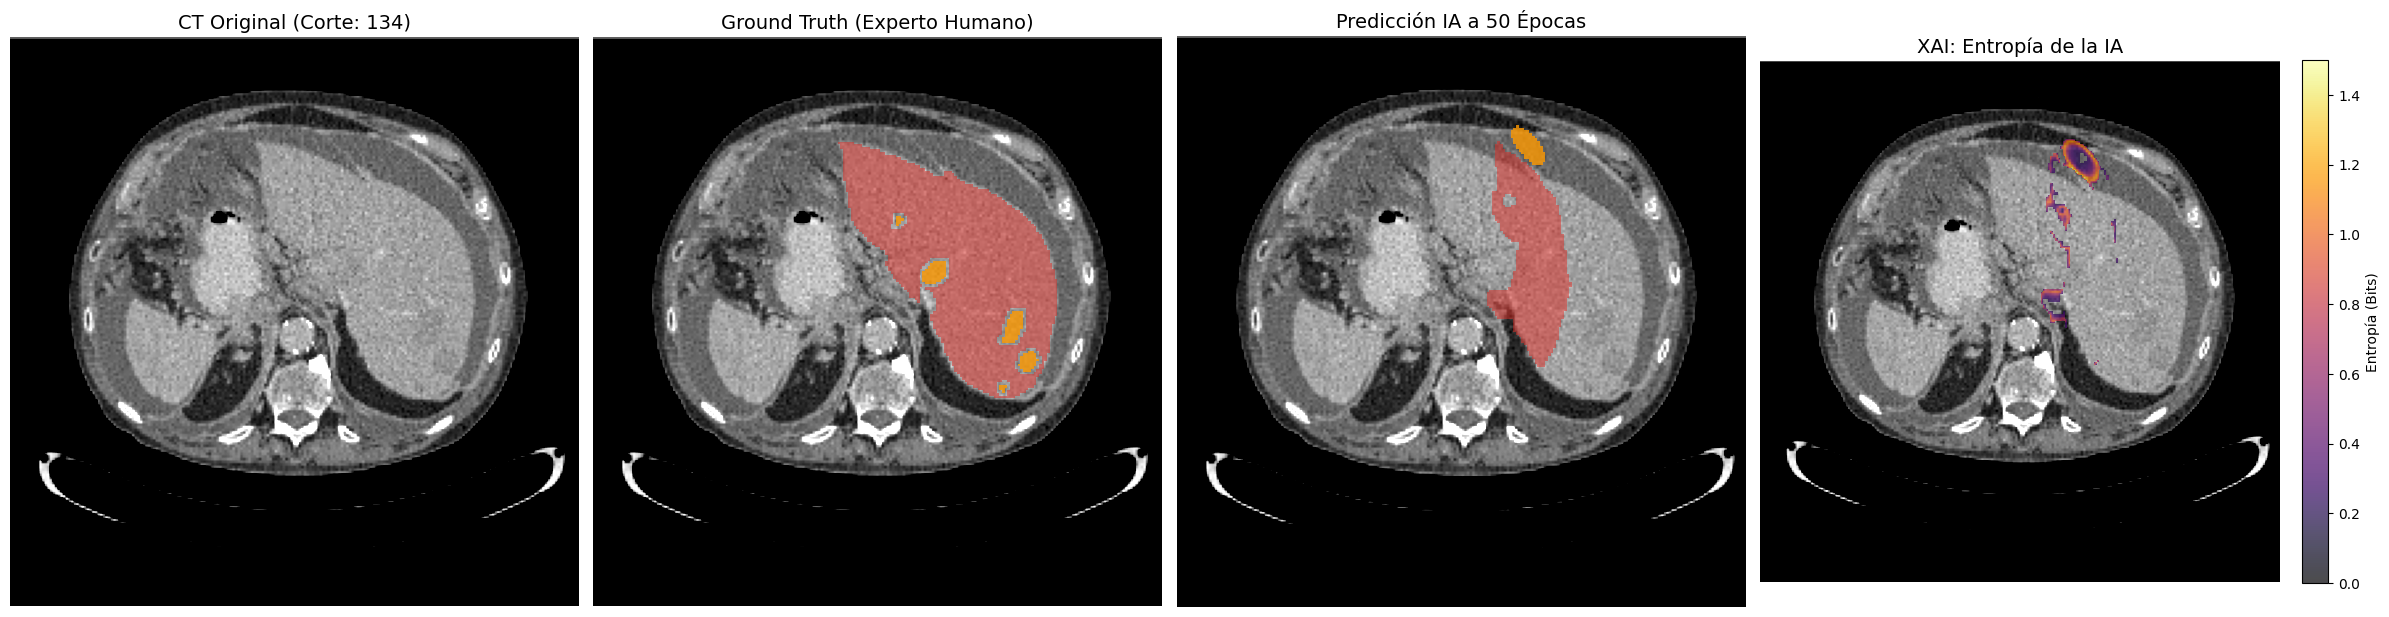

In [33]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# 1. Definir rutas
predict_dir = '/content/nnUNet_Workspace/predictTs'
images_dir = '/content/nnUNet_Workspace/imagesTs'
labels_dir = '/content/nnUNet_Workspace/nnUNet_raw/Dataset101_Liver/labelsTr' # El GPS anatómico

target_patient = 'liver_94'

npz_path = os.path.join(predict_dir, f'{target_patient}.npz')
ct_path = os.path.join(images_dir, f'{target_patient}_0000.nii.gz')
gt_path = os.path.join(labels_dir, f'{target_patient}.nii.gz')

if not os.path.exists(npz_path):
    npz_files = [f for f in os.listdir(predict_dir) if f.endswith('.npz')]
    target_npz = npz_files[0]
    base_name = target_npz.replace('.npz', '')
    npz_path = os.path.join(predict_dir, target_npz)
    ct_path = os.path.join(images_dir, f'{base_name}_0000.nii.gz')
    gt_path = os.path.join(labels_dir, f'{base_name}.nii.gz')
else:
    base_name = target_patient

# 2. Cargar datos
print(f"Cargando paciente: {base_name}")
ct_img = nib.load(ct_path).get_fdata()
probs = np.load(npz_path)['probabilities']
gt_data = nib.load(gt_path).get_fdata() # Ground Truth

# 3. Calcular entropía
entropy_map = -np.sum(probs * np.log2(probs + 1e-8), axis=0)

# 4. EL GPS DEL EXPERTO (Ground Truth)
gt_tumor_mask = (gt_data == 2)
z_gt_tumor_counts = np.sum(gt_tumor_mask, axis=(0, 1))

if np.max(z_gt_tumor_counts) > 0:
    best_z_slice = np.argmax(z_gt_tumor_counts)
    print(f"GPS Clínico: El mayor volumen de tumor REAL está en el corte {best_z_slice}")
else:
    print("Este paciente no tiene tumor real en el Ground Truth. Buscando el centro del hígado...")
    gt_liver_mask = (gt_data == 1)
    best_z_slice = np.argmax(np.sum(gt_liver_mask, axis=(0, 1)))

# 5. Extraer y rotar cortes 2D para visualización radiológica
ct_slice = np.rot90(ct_img[:, :, best_z_slice])
entropy_slice = np.rot90(entropy_map[:, :, best_z_slice])
pred_slice = np.rot90(np.argmax(probs, axis=0)[:, :, best_z_slice])
gt_slice = np.rot90(gt_data[:, :, best_z_slice]) # Extraemos también la verdad

# 6. Visualización Médica Avanzada
plt.figure(figsize=(24, 7))

# Panel 1: CT Original
plt.subplot(1, 4, 1)
plt.title(f"CT Original (Corte: {best_z_slice})", fontsize=14)
plt.imshow(ct_slice, cmap='gray', vmin=-150, vmax=250)
plt.axis('off')

# Panel 2: Ground Truth (La verdad clínica)
plt.subplot(1, 4, 2)
plt.title("Ground Truth (Experto Humano)", fontsize=14)
plt.imshow(ct_slice, cmap='gray', vmin=-150, vmax=250)
gt_liver_overlay = np.ma.masked_where(gt_slice != 1, gt_slice)
gt_tumor_overlay = np.ma.masked_where(gt_slice != 2, gt_slice)
# Forzamos los límites (vmin/vmax) para que el color no se diluya
plt.imshow(gt_liver_overlay, cmap='Reds', alpha=0.5, vmin=0, vmax=1.5)
plt.imshow(gt_tumor_overlay, cmap='Wistia', alpha=0.8, vmin=0, vmax=2.5)
plt.axis('off')

# Panel 3: Predicción de la IA
plt.subplot(1, 4, 3)
plt.title("Predicción IA a 50 Épocas", fontsize=14)
plt.imshow(ct_slice, cmap='gray', vmin=-150, vmax=250)
pred_liver_overlay = np.ma.masked_where(pred_slice != 1, pred_slice)
pred_tumor_overlay = np.ma.masked_where(pred_slice != 2, pred_slice)
plt.imshow(pred_liver_overlay, cmap='Reds', alpha=0.5, vmin=0, vmax=1.5)
plt.imshow(pred_tumor_overlay, cmap='Wistia', alpha=0.8, vmin=0, vmax=2.5)
plt.axis('off')

# Panel 4: Mapa de Incertidumbre (XAI)
plt.subplot(1, 4, 4)
plt.title("XAI: Entropía de la IA", fontsize=14)
plt.imshow(ct_slice, cmap='gray', vmin=-150, vmax=250)
entropy_overlay = np.ma.masked_where(entropy_slice < 0.2, entropy_slice)
im = plt.imshow(entropy_overlay, cmap='inferno', alpha=0.7, vmin=0, vmax=1.5)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Entropía (Bits)")
plt.axis('off')

plt.tight_layout()
plt.show()